# Bank Loan Approval Analysis & Risk Assessment
**Author:** Winjeet Singh

## Project Overview
In this project, we analyze historical bank loan data to identify key patterns in applicant demographics, income, and borrowing habits. The goal is to perform data cleaning, feature engineering, and exploratory data analysis (EDA) to build a foundation for assessing applicant risk. 

Key objectives:
1. Handle missing data appropriately based on data types.
2. Normalize skewed financial data for better algorithmic performance.
3. Segment applicants into 'High Risk' and 'Low Risk' categories based on credit history and income.

## 1. Environment Setup & Data Loading
First, we will import the necessary data science libraries and load our dataset to inspect its structure.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Set a professional visual theme for all plots
sns.set_theme(style="whitegrid", palette="muted")

# Load data and strip whitespace from column names
# Load data using a relative path
df = pd.read_excel("Bank Loan Approval Analysis DataSet.xlsx")
df.columns = df.columns.str.strip()

# Display basic info
display(df.head())

,LoanID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Total Income,Q1_25%,Q2_50%,Q3_75%,Income_Category
0,LP001015,Male,Yes,0.0,Graduate,No,5720,0,110.0,360.0,1.0,Urban,5720,4156,5205,6980,High
1,LP001022,Male,Yes,1.0,Graduate,No,3076,1500,126.0,360.0,1.0,Urban,4576,4156,5205,6980,Medium
2,LP001031,Male,Yes,2.0,Graduate,No,5000,1800,208.0,360.0,1.0,Urban,6800,4156,5205,6980,High
3,LP001035,Male,Yes,2.0,Graduate,No,2340,2546,100.0,360.0,NaN,Urban,4886,4156,5205,6980,Medium
4,LP001051,Male,No,0.0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban,3276,4156,5205,6980,Low


## 2. Data Cleaning & Feature Engineering
Real-world data is rarely perfect. We need to handle missing values before performing any analysis. 
* **Categorical variables** will be filled using the Mode (most frequent class).
* **Numerical variables** will be filled using the Median (to avoid the influence of extreme outliers).

Additionally, financial data like Income and Loan Amounts are usually highly right-skewed. We will combine Applicant and Coapplicant income into a `Total_Income` feature, and apply a **Log Transformation** to normalize the distributions.

In [2]:
# 1. Handle Missing Values Professionally (Modern Pandas Syntax)

# Fill categorical, object, and string columns with Mode
categorical_cols = df.select_dtypes(include=['object', 'category', 'str']).columns
for col in categorical_cols:
    if not df[col].mode().empty:
        # Re-assign instead of using inplace=True to avoid Copy-on-Write warnings
        df[col] = df[col].fillna(df[col].mode()[0])

# Fill strictly numerical columns with Median
numerical_cols = df.select_dtypes(include=['number']).columns
for col in numerical_cols:
    # Re-assign instead of using inplace=True
    df[col] = df[col].fillna(df[col].median())

# Verify missing values are handled
print("Remaining missing values:\n", df.isnull().sum())

# 2. Feature Engineering
# Create Total Income
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']

# Log transformation to reduce extreme skewness
df['Log_Income'] = np.log1p(df['Total_Income'])
df['Log_LoanAmount'] = np.log1p(df['LoanAmount'])

Remaining missing values:
 LoanID               0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Total Income         0
Q1_25%               0
Q2_50%               0
Q3_75%               0
Income_Category      0
dtype: int64


### 2.1 Verifying the Transformation
Let's check the skewness values to ensure our log transformation successfully normalized the financial variables. A skewness value closer to 0 indicates a normal distribution.

In [3]:
print("Skewness Before Transformation:")
print(df[['ApplicantIncome','LoanAmount']].skew())

print("Skewness After Transformation:")
print(df[['Log_Income','Log_LoanAmount']].skew())

Skewness Before Transformation:
ApplicantIncome    8.441375
LoanAmount         2.244601
dtype: float64
Skewness After Transformation:
Log_Income        1.172348
Log_LoanAmount   -0.228775
dtype: float64


## 3. Exploratory Data Analysis (EDA)
Now that our data is clean, let's visualize the financial distributions of our applicants.

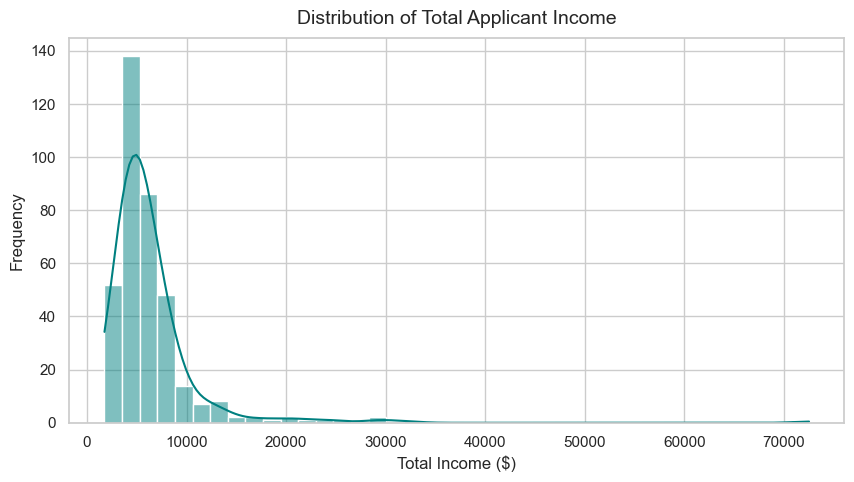

In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Total_Income'], bins=40, kde=True, color='teal')
plt.title("Distribution of Total Applicant Income", fontsize=14, pad=10)
plt.xlabel("Total Income ($)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

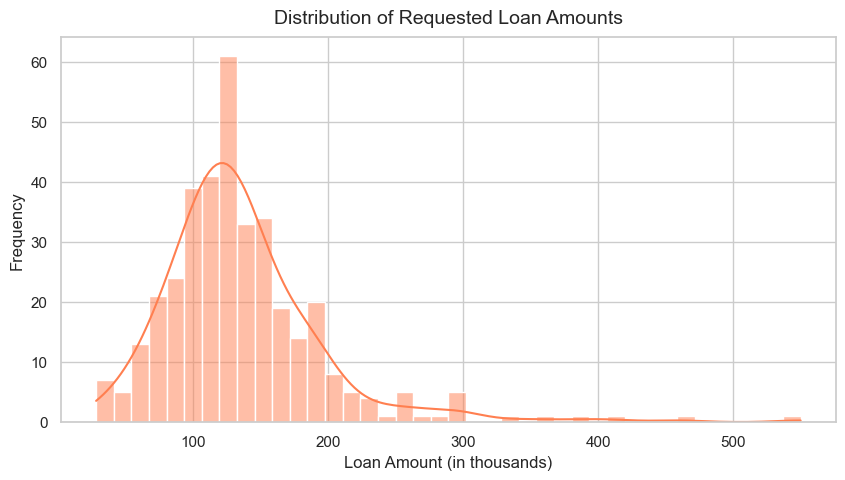

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(df['LoanAmount'], bins=40, kde=True, color='coral')
plt.title("Distribution of Requested Loan Amounts", fontsize=14, pad=10)
plt.xlabel("Loan Amount (in thousands)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

## 4. Statistical Analysis: Income vs. Loan Amount
Does a higher income guarantee a larger loan request? Let's calculate the Pearson correlation coefficient to measure the linear relationship between Total Income and Loan Amount.

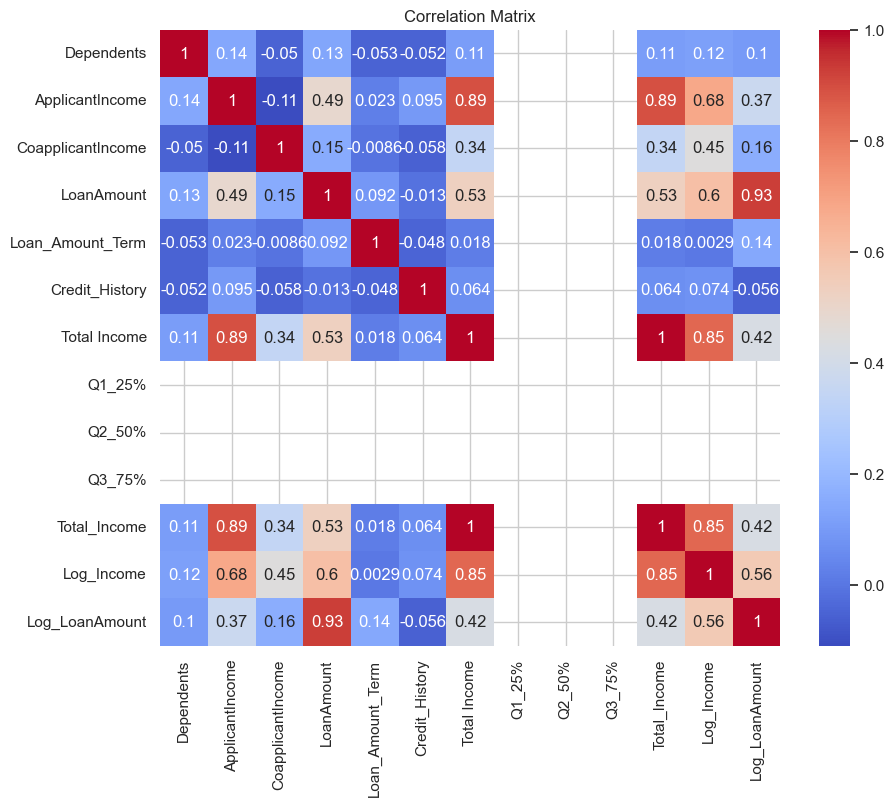

In [6]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

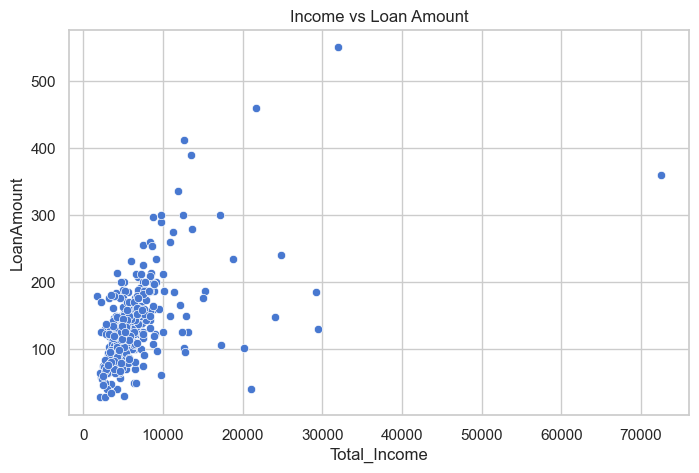

In [7]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Total_Income', y='LoanAmount', data=df)
plt.title("Income vs Loan Amount")
plt.show()

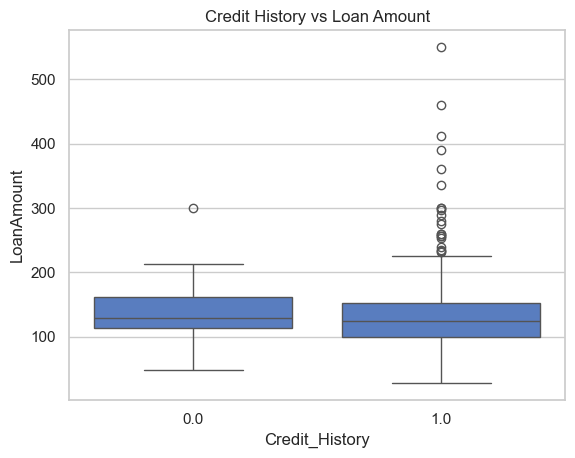

In [8]:
sns.boxplot(x='Credit_History', y='LoanAmount', data=df)
plt.title("Credit History vs Loan Amount")
plt.show()

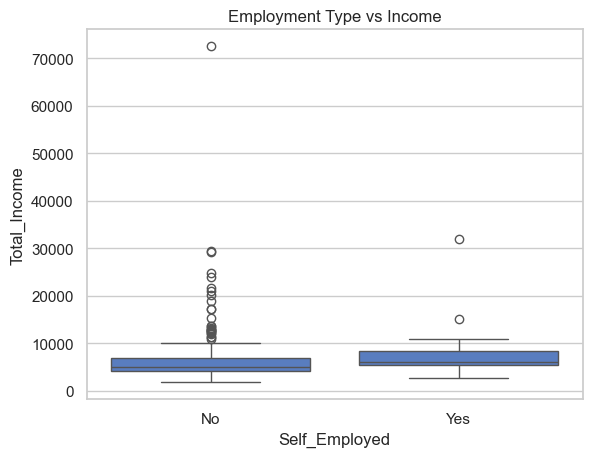

In [9]:
sns.boxplot(x='Self_Employed', y='Total_Income', data=df)
plt.title("Employment Type vs Income")
plt.show()

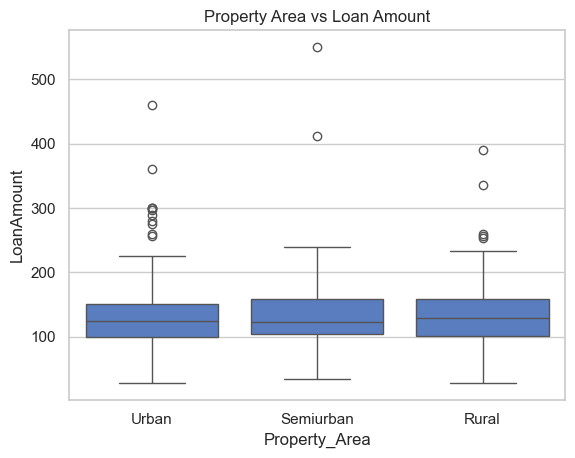

In [10]:
sns.boxplot(x='Property_Area', y='LoanAmount', data=df)
plt.title("Property Area vs Loan Amount")
plt.show()

In [11]:
df['Income_Quartile'] = pd.qcut(df['Total_Income'], 4)

print(df.groupby('Income_Quartile')['LoanAmount'].mean())

Income_Quartile
(1759.999, 4156.0]    100.108696
(4156.0, 5205.0]      121.086957
(5205.0, 6980.0]      133.208791
(6980.0, 72529.0]     189.489130
Name: LoanAmount, dtype: float64


In [12]:
correlation, p_value = stats.pearsonr(df['Total_Income'], df['LoanAmount'])

print("Correlation:", correlation)
print("P-value:", p_value)

Correlation: 0.5289522513385047
P-value: 7.591472248575359e-28


## 5. Custom Risk Segmentation
To make this data actionable for a business, we can create a simple heuristic-based risk metric. 
An applicant is flagged as **"Low Risk"** if they meet two criteria:
1. They have a documented Credit History (`Credit_History == 1.0`).
2. Their `Total_Income` is comfortably above $5,000.

Otherwise, they are flagged as **"High Risk"**.

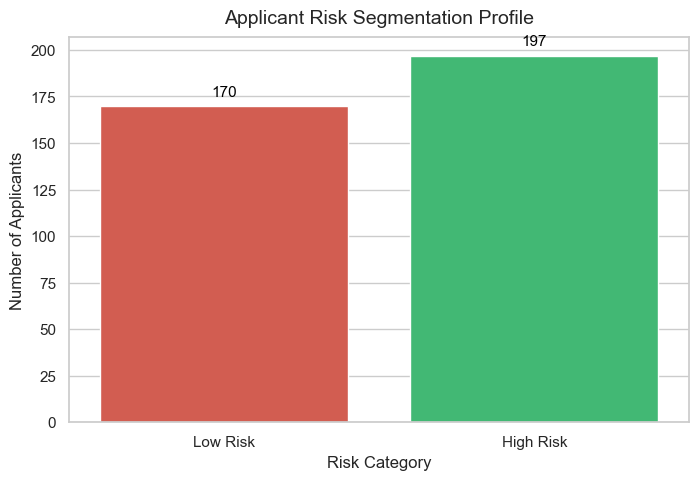

In [13]:
# Create the Risk_Level feature
df['Risk_Level'] = np.where(
    (df['Credit_History'] == 1) & (df['Total_Income'] > 5000),
    "Low Risk",
    "High Risk"
)

# Visualize the Risk Segmentation (Updated for modern Seaborn)
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df, 
    x='Risk_Level', 
    hue='Risk_Level',  # Added this to satisfy modern Seaborn
    palette=['#e74c3c', '#2ecc71'], 
    legend=False       # Added this so we don't get a redundant legend
)
plt.title("Applicant Risk Segmentation Profile", fontsize=14, pad=10)
plt.xlabel("Risk Category", fontsize=12)
plt.ylabel("Number of Applicants", fontsize=12)

# Add data labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

In [14]:
df['Risk_Level'] = np.where(
    (df['Credit_History']==1) & (df['Total_Income']>5000),
    "Low Risk",
    "High Risk"
)

print(df['Risk_Level'].value_counts())

Risk_Level
High Risk    197
Low Risk     170
Name: count, dtype: int64


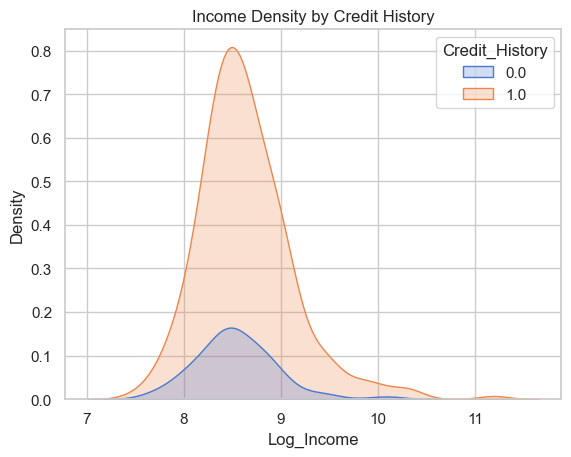

In [15]:
sns.kdeplot(data=df, x='Log_Income', hue='Credit_History', fill=True)
plt.title("Income Density by Credit History")
plt.show()